In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from wordcloud import WordCloud, STOPWORDS
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfTransformer,TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay



In [3]:
df = pd.read_csv("twitter_training.csv")
df.head(5)

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [4]:
df['Positive'].value_counts()

Positive
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [5]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [6]:
df.shape

(74681, 4)

In [7]:
# Naming the columns 
df.columns = ['tweet_id', 'entity', 'sentiment', 'text']

In [8]:
df1 = df.copy()
df1.head()

,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [9]:
df1['entity'].value_counts()

entity
Microsoft                            2400
MaddenNFL                            2400
TomClancysRainbowSix                 2400
LeagueOfLegends                      2394
CallOfDuty                           2394
Verizon                              2382
CallOfDutyBlackopsColdWar            2376
ApexLegends                          2376
Facebook                             2370
WorldOfCraft                         2364
Dota2                                2364
NBA2K                                2352
TomClancysGhostRecon                 2346
Battlefield                          2346
FIFA                                 2340
Overwatch                            2334
Xbox(Xseries)                        2334
johnson&johnson                      2328
Amazon                               2316
HomeDepot                            2310
PlayStation5(PS5)                    2310
CS-GO                                2304
Cyberpunk2077                        2304
GrandTheftAuto(GTA)        

# EDA

In [10]:
df1.isna().sum()

tweet_id       0
entity         0
sentiment      0
text         686
dtype: int64

In [11]:
df1.dropna(inplace= True)

In [12]:
df1.isna().sum()

tweet_id     0
entity       0
sentiment    0
text         0
dtype: int64

In [13]:
df1.shape

(73995, 4)

In [14]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73995 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   73995 non-null  int64 
 1   entity     73995 non-null  object
 2   sentiment  73995 non-null  object
 3   text       73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.8+ MB


In [15]:
df1.describe()

,tweet_id
count,73995.000000
mean,6430.333685
std,3737.655932
min,1.000000
25%,3194.000000
50%,6418.000000
75%,9595.000000
max,13200.000000


In [16]:
df1 = df1.drop(['tweet_id'], axis = 1)
df.head()

,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


C:\Users\bikra\AppData\Local\Temp\ipykernel_11020\852888078.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df1, x = 'sentiment', palette = 'viridis')


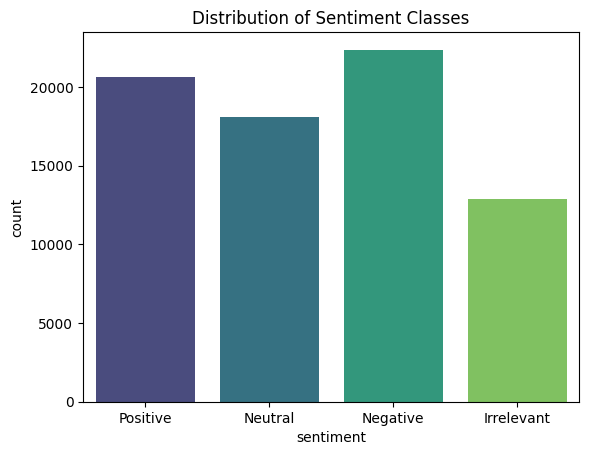

In [45]:
# Check the class imbalance

sns.countplot(data = df1, x = 'sentiment', palette = 'viridis')
plt.title('Distribution of Sentiment Classes')
plt.show()


In [17]:
def clean_twitter_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Strip URLs
    text = re.sub(r'@\w+', '', text)                     # Strip user mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)             # Strip special chars & numbers
    text = re.sub(r'\s+', ' ', text).strip()            # Clean multi-spaces
    return text

In [18]:
df1['cleaned_text'] = df1['text'].apply(clean_twitter_text)
df1.head()

,entity,sentiment,text,cleaned_text
0,Borderlands,Positive,I am coming to the borders and I will kill you...,I am coming to the borders and I will kill you...
1,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
2,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
3,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...
4,Borderlands,Positive,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...


In [19]:
df1['sentiment'].value_counts()

sentiment
Negative      22358
Positive      20654
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

In [49]:
neg_senti = df1[df1["sentiment"]=="Negative"]["cleaned_text"]
pos_senti = df1[df1["sentiment"]== "Positive"]["cleaned_text"]
neutral_senti = df1[df1["sentiment"]== "Neutral"]["cleaned_text"]
irrelevant_senti = df1[df1["sentiment"]== "Irrelevant"]["cleaned_text"]

In [27]:
# custom stopword
custom_stopword = set(STOPWORDS)
'''protected_words = {
    "not",
    "no",
    "never",
    "neither",
    "nor",
    "none",
    "but",
    "however",
    "against",
    "very",
    "most",
}'''

protected_words = {
    "not", "no", "never", "neither", "nor", "none", "cannot", "cant", 
    "dont", "wont", "isnt", "arent", "couldnt", "didnt", "doesnt", 
    "hadnt", "hasnt", "havent", "shouldnt", "wasnt", "werent", "wouldnt",
    "but", "however", "against", "very", "most", "more"
}
#tfidf_stopwords = list(set(ENGLISH_STOP_WORDS) - protected_words)

custom_stopword = custom_stopword.difference(protected_words)
custom_stopword

{'a',
 'about',
 'above',
 'after',
 'again',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'by',
 'can',
 "can't",
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 "mustn't",
 'my',
 'myself',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 'ours',
 'ourselves',
 'out',
 'over',
 'own',
 'r',
 'same',
 'shall',
 "shan't",
 

In [51]:
def creat_word_cloud(text):
    # Create the WordCloud object
    word_cloud = WordCloud(
        width=800, 
        height=400, 
        background_color="white", 
        min_font_size=10,
        stopwords= custom_stopword,
        colormap='viridis'
    ).generate(text)

    # Display the generated image
    plt.figure(figsize=(10, 5))
    plt.imshow(word_cloud, interpolation='bilinear')
    plt.axis('off')  # Hide axes for a cleaner look
    plt.show()

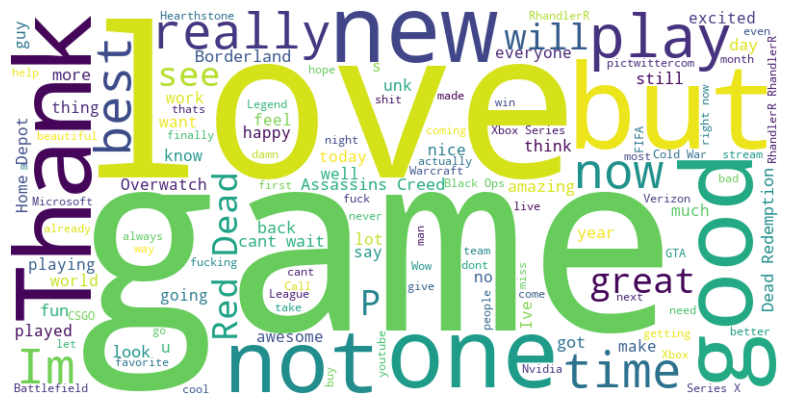

In [52]:
creat_word_cloud(" ".join(pos_senti))

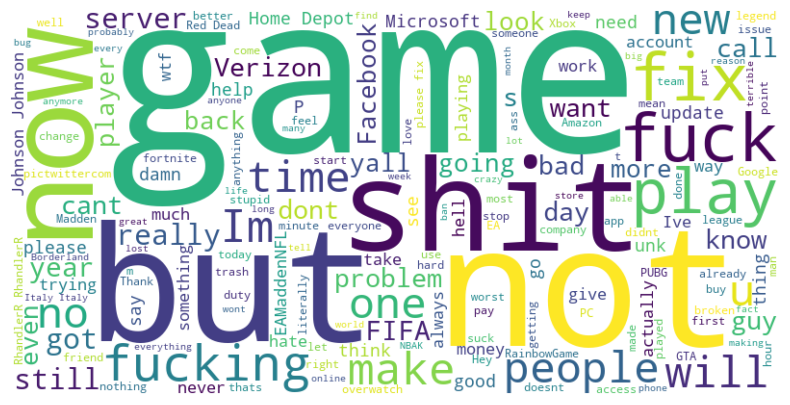

In [53]:
creat_word_cloud(" ".join(neg_senti))

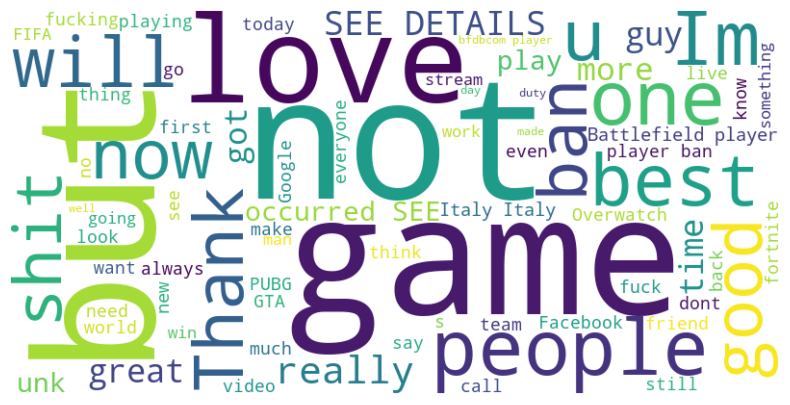

In [54]:
creat_word_cloud(" ".join(irrelevant_senti))

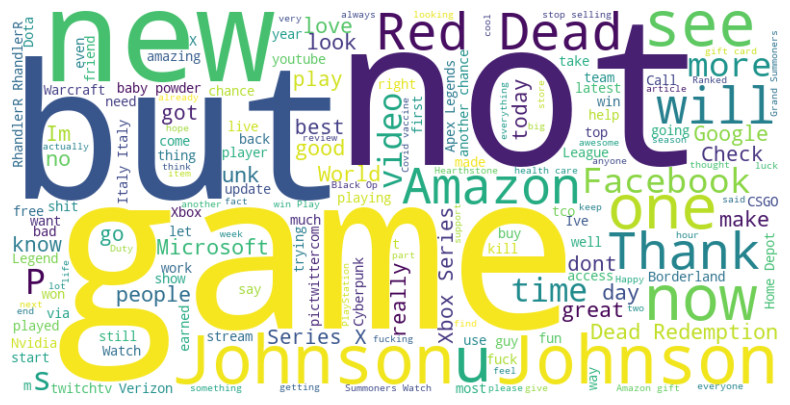

In [55]:
creat_word_cloud(" ".join(neutral_senti))

In [60]:
df1.columns

Index(['entity', 'sentiment', 'text', 'cleaned_text'], dtype='object')

In [20]:
x = df1['entity'] + " " + df1['cleaned_text']
x.head()

0    Borderlands I am coming to the borders and I w...
1    Borderlands im getting on borderlands and i wi...
2    Borderlands im coming on borderlands and i wil...
3    Borderlands im getting on borderlands and i wi...
4    Borderlands im getting into borderlands and i ...
dtype: object

In [21]:
y = df1['sentiment']
y.head()

0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: sentiment, dtype: object

In [22]:
xtrain,xtest,ytrain,ytest = train_test_split(x, y, train_size= 0.8, random_state= 42)

In [28]:
tfidf_stopword = list(custom_stopword)
pipeline = Pipeline([
    (
        'tfidf',TfidfVectorizer(
            ngram_range= (1,2),
            max_features= 30000,
            stop_words= tfidf_stopword
        )
    ),
    (
        'classifier', LogisticRegression(
            class_weight= 'balanced',
            max_iter= 1000,
            random_state= 42
        )
    )
])

In [36]:
# Train Model
reg_model = pipeline.fit(xtrain,ytrain)

c:\Users\bikra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


In [37]:
reg_model.score(xtrain,ytrain)

0.8965301709574971

In [38]:
reg_model.score(xtest,ytest)

0.8102574498276911

In [39]:
def predict_sentiment(entity, raw_text):
    cleaned = clean_twitter_text(raw_text)          # same cleaning as training
    features = entity + " " + cleaned               # same entity + text combo
    pred = pipeline.predict([features])             # note: list, not a bare string
    return pred[0]

# examples
print(predict_sentiment("Borderlands", "I love this game, it's amazing!"))
print(predict_sentiment("FIFA", "worst update ever, totally broken"))
print(predict_sentiment("Google", "just released a new feature today"))

Positive
Negative
Positive


In [40]:
y_pred = pipeline.predict(xtest)

# confusion matrix

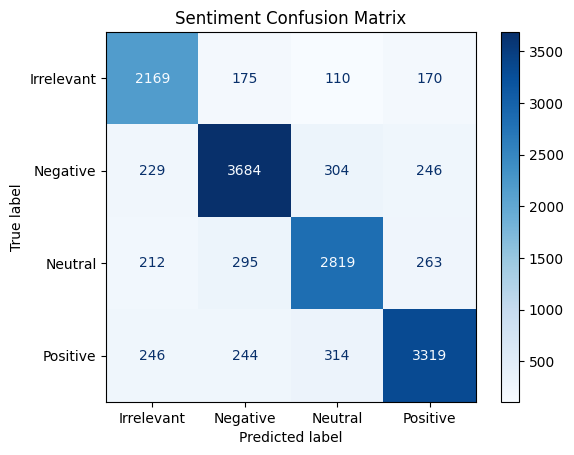

In [48]:
cm = confusion_matrix(ytest, y_pred)
labels = ['Irrelevant',"Negative","Neutral","Positive"]
disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= labels)
disp.plot(cmap= plt.cm.Blues)
plt.title('Sentiment Confusion Matrix')
plt.show()

In [45]:
print(classification_report(ytest, y_pred, digits=4))

              precision    recall  f1-score   support

  Irrelevant     0.7595    0.8266    0.7916      2624
    Negative     0.8377    0.8255    0.8315      4463
     Neutral     0.7948    0.7855    0.7901      3589
    Positive     0.8302    0.8050    0.8174      4123

    accuracy                         0.8103     14799
   macro avg     0.8055    0.8106    0.8076     14799
weighted avg     0.8113    0.8103    0.8105     14799



# Using GridsearchCV

In [49]:
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_features': [20000, 30000],
    'classifier__C':[0.01, 0.1, 0.5, 1.0, 2.0], #[0.1, 1.0, 10.0],
    'classifier__solver': ['lbfgs', 'saga']
}

In [51]:
grid_model = GridSearchCV(
    estimator= pipeline,
    param_grid= param_grid,
    cv = 3,
    scoring= 'f1_macro' # F1-macro accounts for class imbalances well
    
)

In [52]:
grid_reg_model = grid_model.fit(xtrain, ytrain)

c:\Users\bikra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(
c:\Users\bikra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(
c:\Users\bikra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words ma

In [53]:
best_model = grid_model.best_estimator_
best_model

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                                 stop_words=['while', "where's", 'myself',
                                             'com', "shouldn't", "they'll",
                                             'have', 'since', 'few', 'can',
                                             "they've", 'too', 'between',
                                             "there's", 'as', 'until', 'with',
                                             'ought', 'that', 'and', 'once',
                                             'it', "we've", 'above', "here's",
                                             'an', "aren't", 'i', "he's", 'in', ...])),
                ('classifier',
                 LogisticRegression(C=2.0, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

In [54]:
reg_model.score(xtrain, ytrain)

0.8965301709574971

In [55]:
reg_model.score(xtest, ytest)

0.8102574498276911

# Using MultinomialNB to fix the overfit

In [23]:
df1.head()

,entity,sentiment,text,cleaned_text
0,Borderlands,Positive,I am coming to the borders and I will kill you...,I am coming to the borders and I will kill you...
1,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
2,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
3,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...
4,Borderlands,Positive,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...


In [29]:
nb_pipeline = Pipeline([
    (
            'tfidf',TfidfVectorizer(
                ngram_range= (1,2),
                max_features= 30000,
                stop_words= tfidf_stopword
            )
        ),
        (
            'classifier', MultinomialNB()
        )
        
])

In [31]:
naive_model = nb_pipeline.fit(xtrain,ytrain)

In [33]:
naive_model.score(xtrain,ytrain)

0.8301405500371647

In [35]:
naive_model.score(xtest,ytest)

0.7365362524494898

# Logistic regresssion worked better